**simple polinomial regression**



one feature in this degree form for pediction is known as simple polinomal regression

In [ ]:
#loading the datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [ ]:
df=pd.read_csv('Salary_dataset.csv')
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [ ]:
df.shape

(30, 3)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [ ]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [ ]:
#removing the sno column from dataset
df.drop('Unnamed: 0', axis=1, inplace=True)
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1
print("IQR:", IQR)

IQR: YearsExperience        4.5
Salary             43824.0
dtype: float64


In [ ]:
X = df.iloc[:, 0:1].values   # Independent variable (must be 2D)
y = df.iloc[:, 1].values     # Dependent variable

In [ ]:
df_clean = df[(df >= Q1 - 1.5*IQR) & (df <= Q3 + 1.5*IQR)]
df_clean.shape

(30, 2)

In [ ]:
# Create polynomial features (degree =2)
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


In [ ]:
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MSE: 48605815.33188754
RMSE: 6971.787097429722
R2 Score: 0.904842988785486


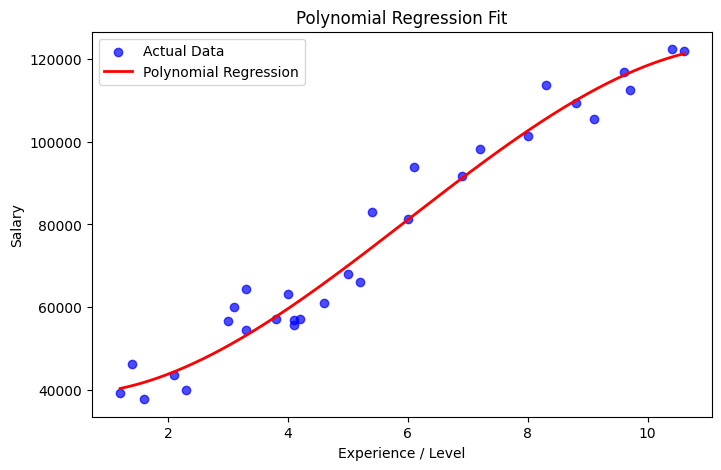

In [ ]:
# Smooth curve for visualization
X_grid = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid)
y_grid_pred = model.predict(X_grid_poly)

plt.figure(figsize=(8,5))
plt.scatter(X, y, color='blue', alpha=0.7, label='Actual Data')
plt.plot(X_grid, y_grid_pred, color='red', linewidth=2, label='Polynomial Regression')

plt.xlabel('Experience / Level')
plt.ylabel('Salary')
plt.title('Polynomial Regression Fit')
plt.legend()
plt.show()


In [ ]:
results=[]
for degree in [1, 2, 3]:
    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    results.append({
        "Degree": degree,
        "Train R2": round(r2_score(y_train, y_train_pred), 4),
        "Test R2": round(r2_score(y_test, y_test_pred), 4)
    })

# Create table
df_results = pd.DataFrame(results)
print(df_results)

   Degree  Train R2  Test R2
0       1    0.9713   0.9048
1       2    0.9739   0.9125
2       3    0.9845   0.8607


In [ ]:
min_degree = 1
max_degree = 20
test_size = 0.2
random_state = 42

In [ ]:
results = []

for degree in range(min_degree, max_degree + 1):
    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    results.append({
        "Degree": degree,
        "Train R2": round(r2_score(y_train, y_train_pred), 4),
        "Test R2": round(r2_score(y_test, y_test_pred), 4)
    })

# -----------------------------
# Display results
# -----------------------------
df_results = pd.DataFrame(results)
print(df_results)

    Degree  Train R2  Test R2
0        1    0.9713   0.9048
1        2    0.9739   0.9125
2        3    0.9845   0.8607
3        4    0.9851   0.8854
4        5    0.9846   0.9017
5        6    0.9634   0.8587
6        7    0.9523   0.7981
7        8    0.9369   0.5145
8        9    0.8420   0.5753
9       10    0.8019   0.5138
10      11    0.7670   0.3847
11      12    0.6848  -0.0528
12      13    0.6650  -0.5939
13      14    0.6486  -1.4083
14      15    0.6356  -2.6620
15      16    0.6255  -4.7087
16      17    0.6177  -8.2472
17      18    0.5560  -0.7416
18      19    0.5501  -1.3259
19      20    0.5446  -2.2242


In [ ]:
under_degree = min_degree
adequate_degree = 3
over_degree = max_degree


In [ ]:
def plot_polynomial_fit(X, y, degree, title):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    # Smooth curve
    X_grid = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
    X_grid_poly = poly.transform(X_grid)
    y_grid_pred = model.predict(X_grid_poly)

    plt.figure(figsize=(7,5))
    plt.scatter(X, y, alpha=0.7, label="Actual Data")
    plt.plot(X_grid, y_grid_pred,color ='red', linewidth=2, label=f"Degree {degree}")
    plt.xlabel("Experience / Level")
    plt.ylabel("Salary")
    plt.title(title)
    plt.legend()
    plt.show()


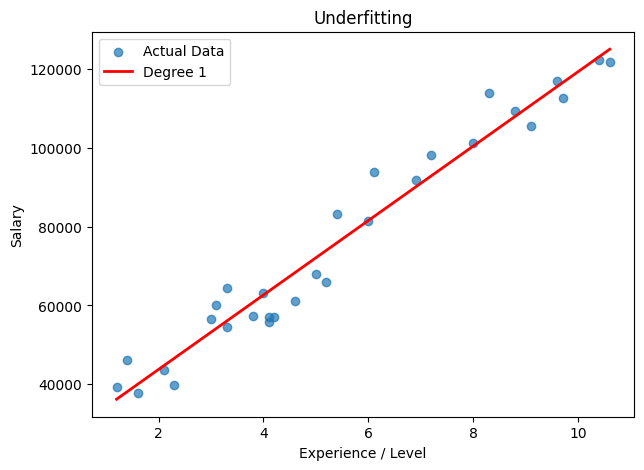

In [ ]:
#underfitting plot
plot_polynomial_fit(
    X, y,
    degree=under_degree,
    title="Underfitting"
)


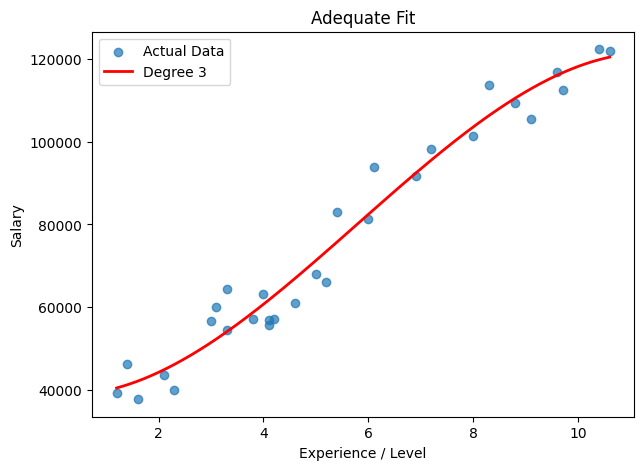

In [ ]:
plot_polynomial_fit(
    X, y,
    degree=adequate_degree,
    title="Adequate Fit"
)


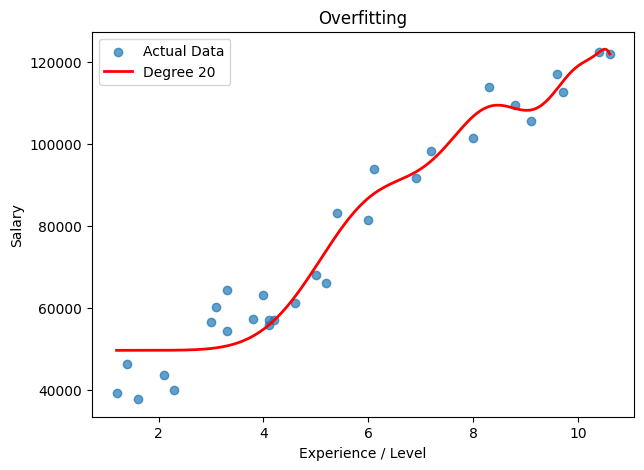

In [ ]:
plot_polynomial_fit(
    X, y,
    degree=over_degree,
    title="Overfitting"
)
